# Step 1: Build a model ready dataset by combining `PubChem + ChEMBL` data

This notebook is the data preparation step of the workflow. It assembles a clean, model ready training set of bioactivity data (`Step0_GetBioactivityData.ipynb`) for the selected `target`. It combines ChEMBL and PubChem records, filters to the target, canonicalizes SMILES,
remove reference drugs and cleans the potency label. The output is a single .csv file that next notebook used to train ML models. No model is trained here.

In [32]:
import os
import warnings

warnings.filterwarnings("ignore")       


from io import BytesIO
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image


# Canonicalization functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

## Configuration

In [33]:
# Set target to any pathogen present in your data
target = "BacillusAnthracis"

# Pathogen class present in your data
targetColumn = "Bacteria"

# File paths
dataDir = "Input_Data/"
resultsDir = os.path.join(f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)


# Datasets to combine. Each entry names its file and its source database
datasets = [
    {"fileName": "allBacteriaData_chEMBL.csv", "source": "ChEMBL", "role": "chemblMaster"},
    {"fileName": "allBacteria_Pubchem.csv", "source": "PubChem", "role": "pubchemMaster"},
]

# Resolve the full path and existence flag for each dataset.
for entry in datasets:
    entry["path"] = os.path.join(dataDir, entry["fileName"])
    entry["exists"] = os.path.exists(entry["path"])

# Map by role so later cells can reference a specific file by name.
byRole = {entry["role"]: entry for entry in datasets}
chemblMasterFile = byRole["chemblMaster"]["path"]
pubchemMasterFile = byRole["pubchemMaster"]["path"]

# Reference drugs to hold out of the training set
ReferenceDrugs = {
    "Basidalin": "C1=C(/C(=C\C=O)/OC1=O)N",
    "Basidalin_Precursor" : "CCC=C1OC(=O)[C@@H](C)[C@H]1O",
    "Gatifloxacin": "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline": "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin": "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G": "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}

print("Target:", target)
print("Results directory:", os.path.abspath(resultsDir))
print("Datasets used:")
for source in sorted({entry["source"] for entry in datasets}):
    print(f"  {source}:")
    for entry in datasets:
        if entry["source"] == source:
            status = "exists" if entry["exists"] else "absent, will skip"
            print(f"    {entry['fileName']}  ({status})")

Target: BacillusAnthracis
Results directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Results_BacillusAnthracis
Datasets used:
  ChEMBL:
    allBacteriaData_chEMBL.csv  (exists)
  PubChem:
    allBacteria_Pubchem.csv  (exists)


## Read potency data for the target from ChEMBL

The ChEMBL master already contains every strain for each target, so a single
filter on `targetColumn` selects all of the target's records.

In [34]:
chemblMaster = pd.read_csv(chemblMasterFile)

# Drop any embedding columns if present (the master is the pre-MACAW uM table).
chemblMaster = chemblMaster.drop(
    columns=[c for c in chemblMaster.columns if "macaw_" in c], errors="ignore"
)

# Keep only the selected target.
targetChemblData = chemblMaster[chemblMaster[targetColumn] == target].copy()

# Drop rows with missing potency.
potencyCols = [c for c in targetChemblData.columns if "potency" in c.lower()]
targetChemblData = targetChemblData.dropna(subset=potencyCols)

targetChemblData

,Unnamed: 0,Bacteria,compound_id,Smiles,pPotency
162379,162379,BacillusAnthracis,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12
162380,162380,BacillusAnthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162381,162381,BacillusAnthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162382,162382,BacillusAnthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162383,162383,BacillusAnthracis,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00
...,...,...,...,...,...
163230,163230,BacillusAnthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.00
163231,163231,BacillusAnthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.00
163232,163232,BacillusAnthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.00
163233,163233,BacillusAnthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.80


### Rename columns to the common schema

In [35]:
targetChemblData = targetChemblData.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
})
targetChemblData = targetChemblData.filter(
    items=["compound_id", "Smiles", "pPotency", targetColumn]
)
targetChemblData

,compound_id,Smiles,pPotency,Bacteria
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,BacillusAnthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,BacillusAnthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,BacillusAnthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,BacillusAnthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,BacillusAnthracis
...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.00,BacillusAnthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.00,BacillusAnthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.00,BacillusAnthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.80,BacillusAnthracis


## Read PubChem bioassay data for the target

In [36]:
targetPubchemData = pd.read_csv(pubchemMasterFile)

# Keep only records for the selected target.
targetPubchemData = targetPubchemData[targetPubchemData[targetColumn] == target]

# Drop rows with missing potency.
potencyCols = [c for c in targetPubchemData.columns if "potency" in c.lower()]
targetPubchemData = targetPubchemData.dropna(subset=potencyCols)

targetPubchemData = targetPubchemData.filter(
    items=["compound_id", "Smiles", "pPotency", targetColumn]
)
targetPubchemData

,compound_id,Smiles,pPotency,Bacteria
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis
...,...,...,...,...
3477,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.920819,BacillusAnthracis
3478,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.958607,BacillusAnthracis
3479,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.346787,BacillusAnthracis
3480,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.468521,BacillusAnthracis


### Combine PubChem + ChEMBL data

In [37]:
targetData_allDB = pd.concat(
    [targetPubchemData, targetChemblData],
    ignore_index=True,
)
targetData_allDB

,compound_id,Smiles,pPotency,Bacteria
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis
...,...,...,...,...
4260,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,BacillusAnthracis
4261,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000,BacillusAnthracis
4262,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000,BacillusAnthracis
4263,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,BacillusAnthracis


### Canonicalize the SMILES

In [38]:
targetData_allDB["Smiles"] = (
    targetData_allDB["Smiles"]
    .astype(str)
    .apply(canonicalizeSmiles)
)

targetData_allDB = targetData_allDB.rename(columns={"Smiles": "Canonical_SMILES"})
targetData_allDB

,compound_id,Canonical_SMILES,pPotency,Bacteria
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis
...,...,...,...,...
4260,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,BacillusAnthracis
4261,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000,BacillusAnthracis
4262,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000,BacillusAnthracis
4263,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,BacillusAnthracis


### Show structures

Saved: Results_BacillusAnthracis/BacillusAnthracis_fourCompounds.png


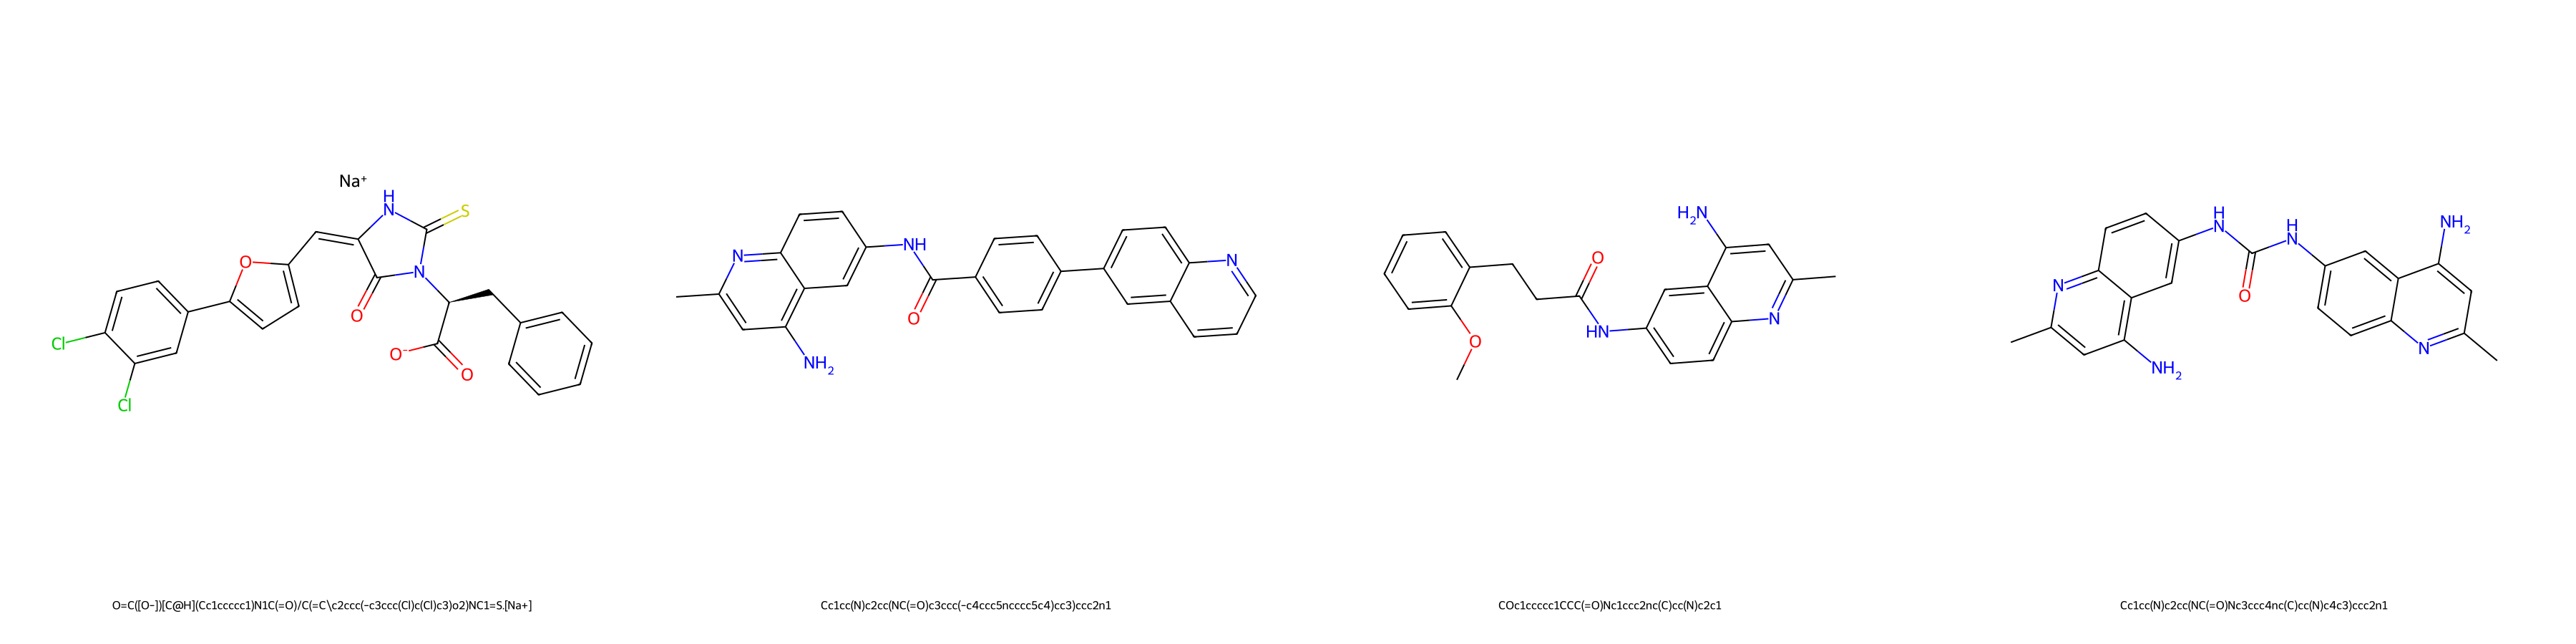

In [39]:
smilesList = targetData_allDB["Canonical_SMILES"].dropna().unique()[:4]

mols = [Chem.MolFromSmiles(str(s)) for s in smilesList]
labels = [str(s) for s in smilesList]

keep = [(m, l) for m, l in zip(mols, labels) if m is not None]
mols = [m for m, _ in keep]
labels = [l for _, l in keep]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(900, 900),      # large pixel size so 600 dpi output stays sharp
    legends=labels,
    useSVG=False,
    returnPNG=False,            # returns a PIL Image
)

# Ensure we have a PIL Image, then save at 600 dpi.
if not isinstance(img, Image.Image):
    img = Image.open(BytesIO(img.data if hasattr(img, "data") else img))

fourCompoundsPath = os.path.join(resultsDir, f"{target}_fourCompounds.png")
img.convert("RGB").save(fourCompoundsPath, format="PNG", dpi=(600, 600))
print("Saved:", fourCompoundsPath)
img

### Remove reference drugs (held out) from the training set

The reference drugs are defined in `ReferenceDrugs` in the job configuration.
They are matched on canonical SMILES and removed so they can serve as an
independent evaluation set. An empty `ReferenceDrugs` removes nothing.

In [40]:
# Canonical SMILES set for all held-out reference drugs.
referenceCanonicalSet = {
    Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
    for smi in ReferenceDrugs.values()
    if Chem.MolFromSmiles(smi) is not None
}

# Canonicalize all SMILES in the dataframe for matching.
df = targetData_allDB.copy()
df["canonical_smiles"] = df["Canonical_SMILES"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    if Chem.MolFromSmiles(s) is not None else None
)

# Remove rows whose canonical SMILES match a held-out reference drug.
dfClean = df[~df["canonical_smiles"].isin(referenceCanonicalSet)].copy()

print(f"Original shape: {len(df)}")
print(f"Removed (matches any reference drug): {len(df) - len(dfClean)}")
print(f"Remaining shape: {len(dfClean)}")

targetData_allDB = dfClean.drop(columns="canonical_smiles")
targetData_allDB

Original shape: 4265
Removed (matches any reference drug): 111
Remaining shape: 4154


,compound_id,Canonical_SMILES,pPotency,Bacteria
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis
...,...,...,...,...
4260,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,BacillusAnthracis
4261,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000,BacillusAnthracis
4262,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000,BacillusAnthracis
4263,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,BacillusAnthracis


### Plot the potency distribution in the training data

In [41]:
# Bins for non-negative values: 0-3, 3-4, ..., 11-12, >12
bins = [0] + list(range(3, 13)) + [np.inf]
labels = ["0-3"] + [f"{i}-{i+1}" for i in range(3, 12)] + ["> 12"]

df = targetData_allDB.copy()

# Coerce to numeric (invalid entries become NaN).
p = pd.to_numeric(df["pPotency"], errors="coerce")

# Build categories including NaN and negatives.
cat = pd.Series(index=df.index, dtype="object")
cat[p.isna()] = "NaN"
cat[(~p.isna()) & (p < 0)] = "<0"

# Categorize non-negative values.
cat[(~p.isna()) & (p >= 0)] = pd.cut(
    p[(~p.isna()) & (p >= 0)],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True,
)

df["pPotency_category"] = cat

order = ["NaN", "<0"] + labels
categoryCounts = df["pPotency_category"].value_counts().reindex(order, fill_value=0)
total = categoryCounts.sum()
categoryPercent = (categoryCounts / total * 100).round(0).astype(int)

potencyDist = pd.DataFrame({
    "pPotency Range": categoryCounts.index.astype(str),
    "Count": categoryCounts.values,
    "Percent (%)": categoryPercent.values,
})

potencyDist

,pPotency Range,Count,Percent (%)
0,NaN,0,0
1,<0,0,0
2,0-3,733,18
3,3-4,551,13
4,4-5,1357,33
5,5-6,761,18
6,6-7,297,7
7,7-8,121,3
8,8-9,95,2
9,9-10,48,1


### Remove NaN, negative, and unphysical (>12) pPotency values

These are removed before cross-validation so the model trains only on physically
sensible potencies.

In [42]:
print("Original shape:", targetData_allDB.shape)

targetData_allDB = targetData_allDB[
    targetData_allDB["pPotency"].notna()
    & targetData_allDB["pPotency"].between(0, 12, inclusive="both")
]

targetData_allDB = targetData_allDB.drop(
    columns=["canonical_smiles", "pPotency_category"],
    errors="ignore",  # prevents error if a column does not exist
)
print("Shape after cleaning 'pPotency' value:", targetData_allDB.shape)
maxVal = targetData_allDB["pPotency"].max()
minVal = targetData_allDB["pPotency"].min()
print(f"pPotency range in training data: {minVal:.2f} to {maxVal:.2f}")

targetData_allDB

Original shape: (4154, 4)
Shape after cleaning 'pPotency' value: (3973, 4)
pPotency range in training data: 0.01 to 12.00


,compound_id,Canonical_SMILES,pPotency,Bacteria
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis
...,...,...,...,...
4257,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,BacillusAnthracis
4259,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,BacillusAnthracis
4260,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,BacillusAnthracis
4263,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,BacillusAnthracis


In [43]:
mlReadyPath = os.path.join(resultsDir, f"{target}Data_allDB_MLready.csv")
targetData_allDB.to_csv(mlReadyPath, index=False)
print("Saved model ready training data to:", mlReadyPath)

Saved model ready training data to: Results_BacillusAnthracis/BacillusAnthracisData_allDB_MLready.csv


### Check for duplicate SMILES in the training data

In [44]:
duplicates = targetData_allDB.duplicated(subset=["Canonical_SMILES", targetColumn])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2329
